In [1]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from stepmix.stepmix import StepMix
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [2]:
overall_df = pd.read_csv("2016_to_2023_full_preprocessed_data_set.csv")

In [3]:
overall_df["VolAny"] = overall_df["VolAny"].fillna(0)

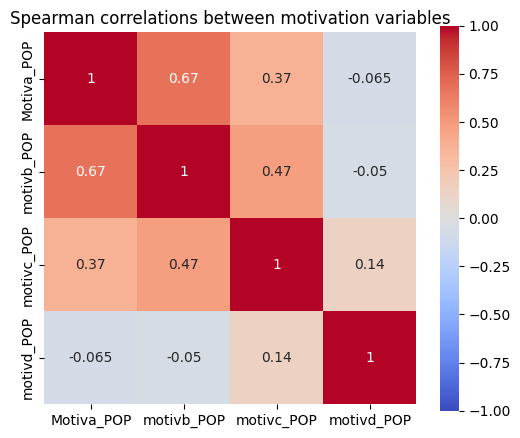

In [4]:
motivation_cols = ["Motiva_POP", "motivb_POP", "motivc_POP", "motivd_POP"]

corr = overall_df[motivation_cols].corr(method="spearman")

plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1, square=True)

plt.title("Spearman correlations between motivation variables")
plt.show()

In [5]:
motivation_cols = ["Motiva_POP", "motivb_POP", "motivc_POP"]

motivation_df = overall_df[motivation_cols].dropna().copy()

scaler = StandardScaler()
motivation_scaled = scaler.fit_transform(motivation_df)

pca = PCA(n_components=1)
pc1 = pca.fit_transform(motivation_scaled).flatten()

print(f"PC1 explains {pca.explained_variance_ratio_[0]:.3f} of the variance")

motivation_df["Motivation_PC"] = pc1

overall_df = overall_df.merge(motivation_df[["Motivation_PC"]], left_index=True, right_index=True, how="left")

PC1 explains 0.666 of the variance


In [6]:
loadings = pd.DataFrame(pca.components_.T, index=motivation_cols, columns=["Loading"])

print(loadings)

             Loading
Motiva_POP  0.588287
motivb_POP  0.625731
motivc_POP  0.512229


In [7]:
input_cols = ["Age9",
              "Gend3",
              "Eth7",
              "Disab3",
              "NSSEC5",
              "Educ6",
              "Child4",
              "IMD10",
              "WorkStat5",
              "VolAny",
              "Motivation_PC"]
  
cluster_df = overall_df[input_cols + ["year"]].dropna().copy()

cluster_df["Motivation_PC_Q"] = (pd.qcut(cluster_df["Motivation_PC"], q=5, labels=False).astype(int))

cluster_df = cluster_df.drop(columns="Motivation_PC")

In [8]:
cluster_cols = ["Age9",
                "Gend3",
                "Eth7",
                "Disab3",
                "NSSEC5",
                "Educ6",
                "Child4",
                "IMD10",
                "WorkStat5",
                "VolAny",
                "Motivation_PC_Q"]

for col in cluster_cols:
    print(cluster_df[col].value_counts(dropna=False))

Age9
4.0    19999
3.0    18402
5.0    16143
6.0    13887
7.0    10762
2.0     7485
8.0      537
9.0      139
Name: count, dtype: int64
Gend3
2.0    48776
1.0    38390
3.0      188
Name: count, dtype: int64
Eth7
1.0    46463
2.0    15340
3.0    12392
4.0     5583
6.0     3075
7.0     2456
5.0     2045
Name: count, dtype: int64
Disab3
3.0    63776
2.0    12961
1.0    10617
Name: count, dtype: int64
NSSEC5
1.0    57604
2.0    15588
3.0     7339
4.0     6147
5.0      676
Name: count, dtype: int64
Educ6
1.0    61300
2.0     9705
3.0     9305
6.0     3275
5.0     2709
4.0     1060
Name: count, dtype: int64
Child4
1.0    60325
2.0    12962
3.0    10878
4.0     3189
Name: count, dtype: int64
IMD10
2.0     13952
3.0     12916
4.0     10877
5.0      9705
6.0      8852
7.0      7511
9.0      7211
8.0      6877
1.0      5602
10.0     3851
Name: count, dtype: int64
WorkStat5
1.0    59955
3.0    16291
4.0     4993
2.0     3706
5.0     2409
Name: count, dtype: int64
VolAny
0.0    75559
1.0    11795
N

In [9]:
len(cluster_df)

87354

In [10]:
X = cluster_df[cluster_cols].copy().astype(int)

for col in X.columns:
    X[col] = X[col] - X[col].min()
    
X.head()

,Age9,Gend3,Eth7,Disab3,NSSEC5,Educ6,Child4,IMD10,WorkStat5,VolAny,Motivation_PC_Q
0,0,0,3,2,0,0,1,1,0,1,1
1,2,0,3,2,1,0,0,3,0,0,3
2,2,1,0,2,0,0,0,6,0,0,2
3,2,0,1,2,0,0,1,3,0,0,4
4,2,1,1,0,0,0,1,3,0,0,0


In [11]:
results = []

for k in range(12, 26):

    try:
    
        print(f"Fitting {k} classes...")

        model = StepMix(n_components=k,  measurement="categorical", random_state=42, n_init=30, max_iter=5000, abs_tol=1e-5)

        model.fit(X)

        proportions = model.predict_proba(X).mean(axis=0)

        results.append({"Classes": k,
                        "LogLik": model.score(X) * len(X),
                        "AIC": model.aic(X),
                        "BIC": model.bic(X),
                        "Converged": model.converged_,
                        "Iterations": model.n_iter_,
                        "MinClass": proportions.min(),
                        "MaxClass": proportions.max()})
        
    except Exception as e:
        results.append({"Classes": k, "Error": str(e)})

    pd.DataFrame(results).to_csv("stepmix_new_latent_class_analysis_results.csv", index=False)

Fitting 12 classes...
Fitting StepMix...


Initializations (n_init) : 100%|██████████| 30/30 [15:59<00:00, 31.99s/it, max_LL=-1.03e+6, max_avg_LL=-11.8]


Fitting 13 classes...
Fitting StepMix...


Initializations (n_init) : 100%|██████████| 30/30 [19:43<00:00, 39.44s/it, max_LL=-1.03e+6, max_avg_LL=-11.8]


Fitting 14 classes...
Fitting StepMix...


...

Initializations (n_init) : 100%|██████████| 30/30 [28:15<00:00, 56.53s/it, max_LL=-1.03e+6, max_avg_LL=-11.8]


Fitting 24 classes...
Fitting StepMix...


Initializations (n_init) : 100%|██████████| 30/30 [59:23<00:00, 118.78s/it, max_LL=-1.03e+6, max_avg_LL=-11.8]


Fitting 25 classes...
Fitting StepMix...


Initializations (n_init) : 100%|██████████| 30/30 [1:00:39<00:00, 121.32s/it, max_LL=-1.03e+6, max_avg_LL=-11.8]


In [12]:
results_df = pd.DataFrame(results)

print(results_df)

    Classes        LogLik           AIC           BIC  Converged  Iterations  \
0        12 -1.034517e+06  2.070183e+06  2.075576e+06       True         241   
1        13 -1.033512e+06  2.068269e+06  2.074112e+06       True         163   
2        14 -1.032864e+06  2.067071e+06  2.073363e+06       True         240   
3        15 -1.032152e+06  2.065741e+06  2.072484e+06       True         170   
4        16 -1.031323e+06  2.064181e+06  2.071373e+06       True         235   
5        17 -1.030882e+06  2.063394e+06  2.071037e+06       True         406   
6        18 -1.030387e+06  2.062500e+06  2.070593e+06       True         323   
7        19 -1.029844e+06  2.061510e+06  2.070053e+06       True         159   
8        20 -1.029515e+06  2.060949e+06  2.069942e+06       True         380   
9        21 -1.028998e+06  2.060011e+06  2.069454e+06       True         332   
10       22 -1.028684e+06  2.059477e+06  2.069371e+06       True         458   
11       23 -1.028501e+06  2.059208e+06 

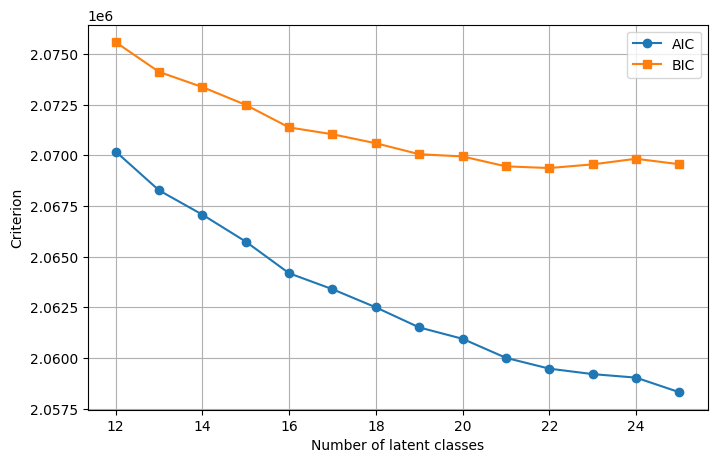

In [13]:
plt.figure(figsize=(8,5))

plt.plot(results_df["Classes"],
         results_df["AIC"],
         marker="o",
         label="AIC")

plt.plot(results_df["Classes"],
         results_df["BIC"],
         marker="s",
         label="BIC")

plt.xlabel("Number of latent classes")
plt.ylabel("Criterion")

plt.legend()

plt.grid(True)

plt.show()